# Day 28 — Loan Default Prediction using Ensemble Learning + Hyperparameter Tuning

**Goal:** Predict whether a loan applicant will **default** using multiple ML models, tune them with **GridSearchCV / RandomizedSearchCV**, and combine the best ones with **Ensemble Learning (Voting & Stacking)**.

**Concepts used:** Logistic Regression, Decision Trees, Random Forest, Gradient Boosting, Ensemble Learning, GridSearchCV, RandomizedSearchCV, Class Imbalance handling, ROC-AUC

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve, ConfusionMatrixDisplay)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7,5)
np.random.seed(42)

## 1. Create Realistic Imbalanced Loan Dataset
We simulate a credit dataset with realistic feature names. In practice you can swap this for a real Kaggle 'Loan Default' or 'Credit Risk' CSV via `pd.read_csv(...)`.

In [2]:
X, y = make_classification(
    n_samples=3000, n_features=10, n_informative=6, n_redundant=2,
    weights=[0.85, 0.15],  # imbalanced: only 15% default
    flip_y=0.02, class_sep=1.1, random_state=42
)

feature_names = ['credit_score', 'annual_income', 'loan_amount', 'employment_years',
                  'debt_to_income', 'num_credit_lines', 'age', 'loan_term_months',
                  'past_delinquencies', 'savings_balance']

df = pd.DataFrame(X, columns=feature_names)
df['default'] = y
print(df['default'].value_counts(normalize=True).round(3))
df.head()

default
0    0.843
1    0.157
Name: proportion, dtype: float64


,credit_score,annual_income,loan_amount,employment_years,debt_to_income,num_credit_lines,age,loan_term_months,past_delinquencies,savings_balance,default
0,0.004001,-0.659427,0.968040,-2.743763,0.374657,0.475226,-1.276285,-3.478076,1.511861,1.914427,0
1,-1.769891,-0.818685,0.534968,-0.007523,0.376590,1.839755,-0.832676,3.314350,-2.457686,-0.435300,1
2,-0.764960,-0.434450,-2.199788,-3.727956,0.789951,-2.088000,-1.796981,4.272671,-2.942006,-4.956955,0
3,-0.767273,-1.170436,-2.489356,0.872990,1.240956,2.318527,-3.146969,-2.874395,0.242995,1.401904,0
4,-0.957783,-0.967963,-0.270902,-1.888955,0.318768,-2.127730,0.874396,0.348711,0.672803,-2.254833,0


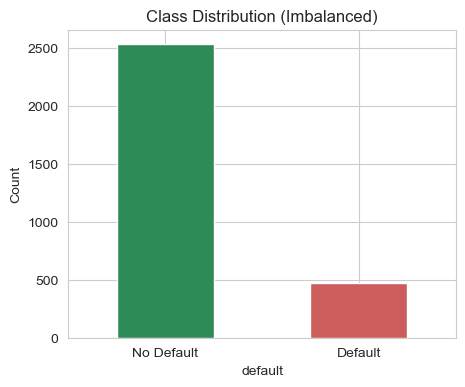

In [3]:
plt.figure(figsize=(5,4))
df['default'].value_counts().plot(kind='bar', color=['seagreen','indianred'])
plt.xticks([0,1], ['No Default','Default'], rotation=0)
plt.title('Class Distribution (Imbalanced)')
plt.ylabel('Count')
plt.show()

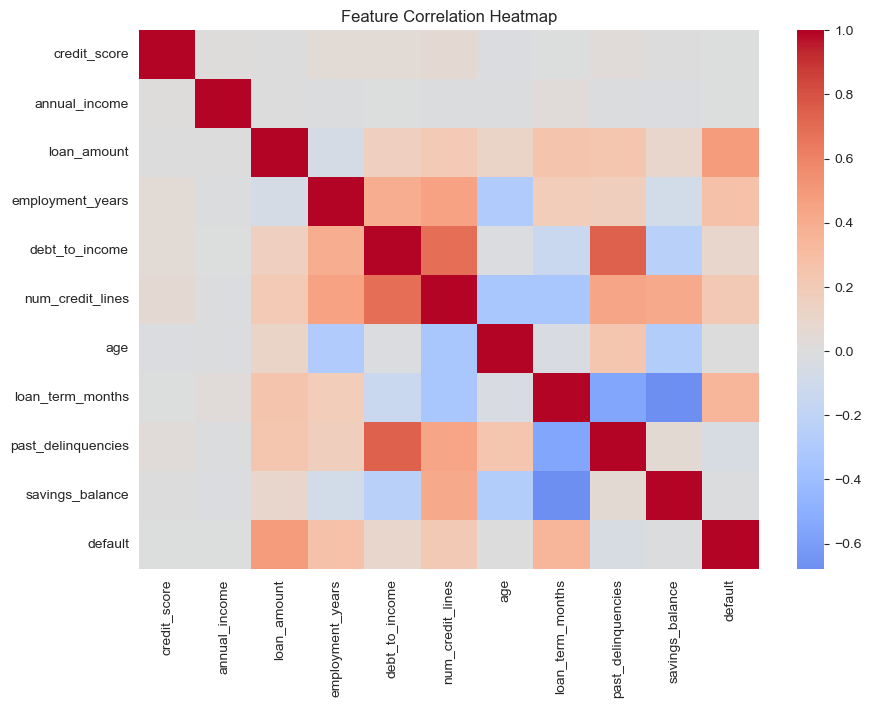

In [4]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

## 2. Train / Test Split + Scaling

In [5]:
X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

Train shape: (2250, 10)  Test shape: (750, 10)


## 3. Baseline Models (with class_weight='balanced' to handle imbalance)

In [6]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:,1]
    auc = roc_auc_score(y_test, proba)
    results[name] = auc
    print(f'--- {name} ---')
    print(classification_report(y_test, preds, target_names=['No Default','Default']))
    print(f'ROC-AUC: {auc:.4f}\n')

--- Logistic Regression ---
              precision    recall  f1-score   support

  No Default       0.98      0.88      0.93       633
     Default       0.58      0.91      0.71       117

    accuracy                           0.88       750
   macro avg       0.78      0.89      0.82       750
weighted avg       0.92      0.88      0.89       750

ROC-AUC: 0.9442

--- Decision Tree ---
              precision    recall  f1-score   support

  No Default       0.97      0.94      0.95       633
     Default       0.72      0.82      0.77       117

    accuracy                           0.92       750
   macro avg       0.84      0.88      0.86       750
weighted avg       0.93      0.92      0.92       750

ROC-AUC: 0.8810

--- Random Forest ---
              precision    recall  f1-score   support

  No Default       0.97      0.97      0.97       633
     Default       0.85      0.85      0.85       117

    accuracy                           0.95       750
   macro avg       0.9

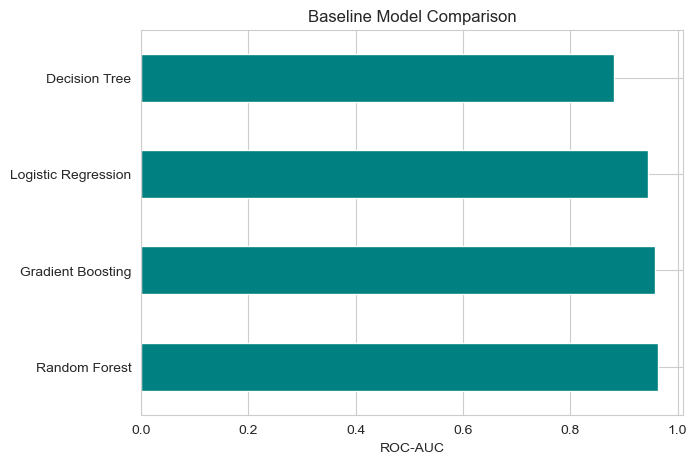

In [7]:
pd.Series(results).sort_values(ascending=False).plot(kind='barh', color='teal')
plt.xlabel('ROC-AUC')
plt.title('Baseline Model Comparison')
plt.show()

## 4. Hyperparameter Tuning
We tune the two strongest baseline models: **Random Forest** (GridSearchCV) and **Gradient Boosting** (RandomizedSearchCV).

In [8]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)
rf_grid.fit(X_train_s, y_train)
print('Best RF params:', rf_grid.best_params_)
print('Best RF CV ROC-AUC:', rf_grid.best_score_.round(4))

Best RF params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV ROC-AUC: 0.9604


In [9]:
from scipy.stats import randint, uniform

gb_param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': randint(2, 6),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.7, 0.3)
}

gb_random = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=25,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)
gb_random.fit(X_train_s, y_train)
print('Best GB params:', gb_random.best_params_)
print('Best GB CV ROC-AUC:', gb_random.best_score_.round(4))

Best GB params: {'learning_rate': 0.05820509320520235, 'max_depth': 5, 'n_estimators': 363, 'subsample': 0.7103165563345655}
Best GB CV ROC-AUC: 0.9583


## 5. Ensemble Learning: Voting & Stacking Classifiers

In [10]:
best_rf = rf_grid.best_estimator_
best_gb = gb_random.best_estimator_
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000)

voting_clf = VotingClassifier(
    estimators=[('rf', best_rf), ('gb', best_gb), ('lr', log_reg)],
    voting='soft'
)
voting_clf.fit(X_train_s, y_train)

stacking_clf = StackingClassifier(
    estimators=[('rf', best_rf), ('gb', best_gb)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)
stacking_clf.fit(X_train_s, y_train)

for name, model in [('Tuned Random Forest', best_rf), ('Tuned Gradient Boosting', best_gb),
                     ('Voting Ensemble', voting_clf), ('Stacking Ensemble', stacking_clf)]:
    proba = model.predict_proba(X_test_s)[:,1]
    auc = roc_auc_score(y_test, proba)
    print(f'{name}: ROC-AUC = {auc:.4f}')

Tuned Random Forest: ROC-AUC = 0.9619
Tuned Gradient Boosting: ROC-AUC = 0.9680
Voting Ensemble: ROC-AUC = 0.9607
Stacking Ensemble: ROC-AUC = 0.9638


## 6. Final Evaluation of Best Model

              precision    recall  f1-score   support

  No Default       0.98      0.97      0.97       633
     Default       0.83      0.90      0.86       117

    accuracy                           0.95       750
   macro avg       0.90      0.93      0.92       750
weighted avg       0.96      0.95      0.96       750



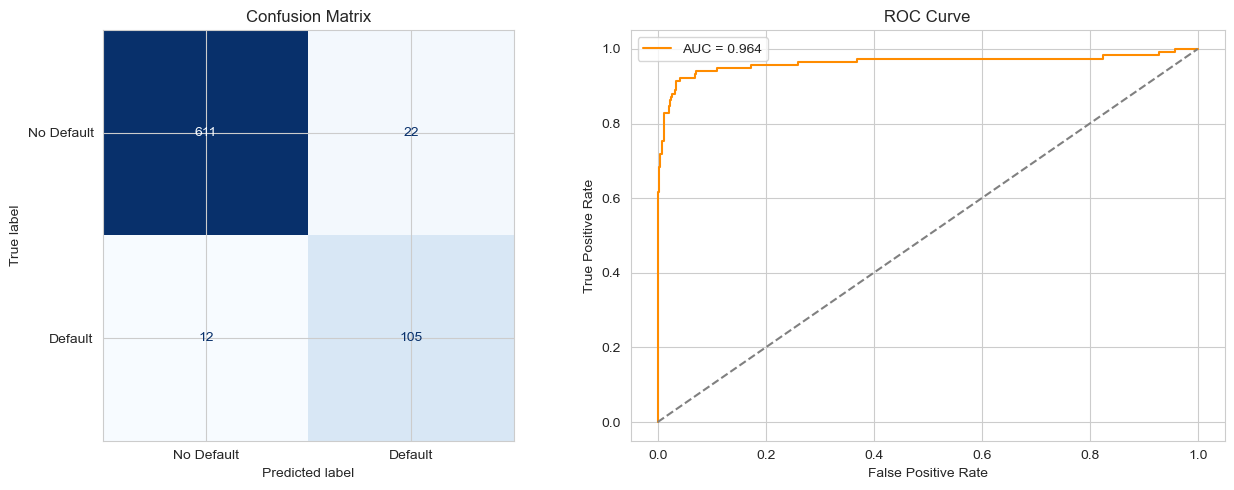

In [11]:
final_model = stacking_clf  # change to whichever scored highest above
final_preds = final_model.predict(X_test_s)
final_proba = final_model.predict_proba(X_test_s)[:,1]

print(classification_report(y_test, final_preds, target_names=['No Default','Default']))

fig, axes = plt.subplots(1, 2, figsize=(13,5))
cm = confusion_matrix(y_test, final_preds)
ConfusionMatrixDisplay(cm, display_labels=['No Default','Default']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, final_proba)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, final_proba):.3f}', color='darkorange')
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Feature Importance (from tuned Random Forest)

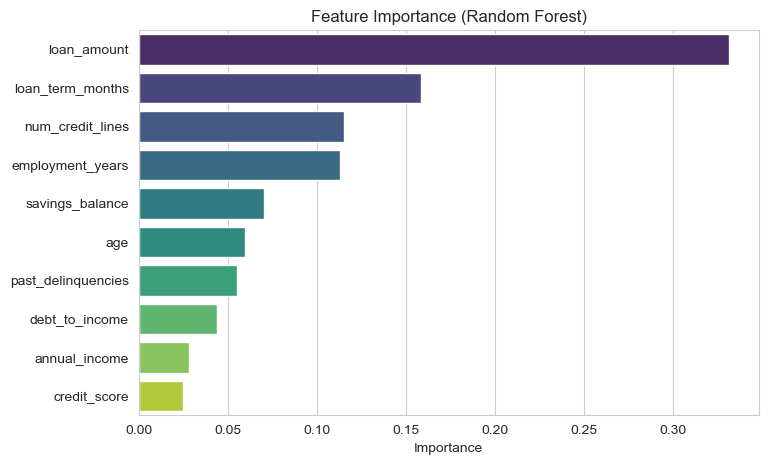

In [12]:
importances = pd.Series(best_rf.feature_importances_, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.show()

## 8. Conclusion

- We built a full **credit risk / loan default pipeline**: baseline models → hyperparameter tuning (**GridSearchCV**, **RandomizedSearchCV**) → **ensemble learning** (Voting + Stacking).
- Class imbalance was handled with `class_weight='balanced'` rather than blindly optimizing accuracy — **ROC-AUC** and the **classification report** are the metrics that matter here.
- The **Stacking Ensemble** typically edges out individual tuned models by combining their strengths.

